# 0. Подготовка данных

In [41]:
import pandas as pd
import numpy as np

# Путь к данным
DATA_DIR = r'C:\Users\User\TPU\MethodsAI\MethodsAI_lab3'

# 1. Загрузка обучающей выборки
data_train = pd.read_excel(f'{DATA_DIR}\\Data_Set_(A+B).xlsx')

# Проверка: какие типы поверхностей присутствуют
print(data_train['Type'].value_counts())

# 2. Формирование целевой переменной Y (бинарная)
#    Type == 1 -> класс 1, остальные -> класс 0
Y = (data_train['Type'] == 1).astype(int)

# 3. Формирование матрицы признаков X только для {V1}
features_V1 = ['N1', 'N2', 'N3',      # энкодеры
               'I1', 'I2', 'I3',      # токи
               'gx', 'gy', 'gz',      # гироскоп
               'ax', 'ay', 'az']      # акселерометр

X = data_train[features_V1].copy()

# 4. Проверка формы и отсутствия пропусков
print(f'Размер X: {X.shape}, размер Y: {Y.shape}')
print('Пропуски в X:', X.isnull().sum().sum())
print('Распределение классов:\n', Y.value_counts())

# 5. Сохранение обработанных данных (опционально)
np.savez(f'{DATA_DIR}\\processed_train_V1.npz', X=X.values, Y=Y.values, feature_names=features_V1)

# 6. подготовка для контрольной выборки
data_C = pd.read_excel(f'{DATA_DIR}\\Data_Set_C.xlsx')
Y_C = (data_C['Type'] == 1).astype(int)
X_C = data_C[features_V1].copy()

Type
2    36
4    36
5    36
1    35
3    33
Name: count, dtype: int64
Размер X: (176, 12), размер Y: (176,)
Пропуски в X: 0
Распределение классов:
 Type
0    141
1     35
Name: count, dtype: int64


# 1. Предварительная серия экспериментов

In [42]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score
import itertools

RANDOM_STATE = 42

# Сетка гиперпараметров (можно сузить после первых тестов)
hidden_layer_sizes_list = [(10,), (50,), (100,), (50, 50)]
activations = ['relu', 'logistic', 'tanh']
solvers = ['adam', 'lbfgs', 'sgd']
max_iters = [200, 500, 1000]
cv_folds = 3

combinations = list(itertools.product(hidden_layer_sizes_list, activations, solvers, max_iters))
results = []

for hidden, activation, solver, max_iter in combinations:
    try:
        # Ручная кросс-валидация с sample_weight
        skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
        cv_f1_scores = []
        
        for train_idx, val_idx in skf.split(X, Y):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            Y_train, Y_val = Y.iloc[train_idx], Y.iloc[val_idx]
            
            # Вычисляем веса для обучающей подвыборки (balanced)
            class_counts = np.bincount(Y_train)
            class_weights = {0: 1.0 / class_counts[0], 1: 1.0 / class_counts[1]}
            sample_weights = Y_train.map(class_weights).values
            
            mlp = MLPClassifier(
                hidden_layer_sizes=hidden,
                activation=activation,
                solver=solver,
                max_iter=max_iter,
                random_state=RANDOM_STATE,
                early_stopping=False
            )
            mlp.fit(X_train, Y_train, sample_weight=sample_weights)
            Y_pred_val = mlp.predict(X_val)
            f1 = f1_score(Y_val, Y_pred_val, pos_label=1, zero_division=0)
            cv_f1_scores.append(f1)
        
        cv_f1_mean = np.mean(cv_f1_scores)
        cv_f1_std = np.std(cv_f1_scores)
        
        # Обучение на всей выборке с весами для итоговой оценки
        class_counts_all = np.bincount(Y)
        class_weights_all = {0: 1.0 / class_counts_all[0], 1: 1.0 / class_counts_all[1]}
        sample_weights_all = Y.map(class_weights_all).values
        
        mlp_all = MLPClassifier(
            hidden_layer_sizes=hidden,
            activation=activation,
            solver=solver,
            max_iter=max_iter,
            random_state=RANDOM_STATE,
            early_stopping=False
        )
        mlp_all.fit(X, Y, sample_weight=sample_weights_all)
        Y_pred_all = mlp_all.predict(X)
        train_acc = accuracy_score(Y, Y_pred_all)
        train_f1 = f1_score(Y, Y_pred_all, pos_label=1, zero_division=0)
        
        results.append({
            'hidden_layers': hidden,
            'activation': activation,
            'solver': solver,
            'max_iter': max_iter,
            'cv_f1_mean': cv_f1_mean,
            'cv_f1_std': cv_f1_std,
            'train_accuracy': train_acc,
            'train_f1': train_f1
        })
        print(f"OK: {hidden}, {activation}, {solver}, iter={max_iter} -> "
              f"CV F1={cv_f1_mean:.3f}±{cv_f1_std:.3f}, train F1={train_f1:.3f}")
    except Exception as e:
        print(f"FAIL: {hidden}, {activation}, {solver}, iter={max_iter}: {str(e)[:80]}")

res_df = pd.DataFrame(results)
print("\nТоп-10 моделей по среднему F1 кросс-валидации:")
print(res_df.sort_values('cv_f1_mean', ascending=False).head(10))

OK: (10,), relu, adam, iter=200 -> CV F1=0.263±0.050, train F1=0.264
OK: (10,), relu, adam, iter=500 -> CV F1=0.263±0.050, train F1=0.264
OK: (10,), relu, adam, iter=1000 -> CV F1=0.263±0.050, train F1=0.264
OK: (10,), relu, lbfgs, iter=200 -> CV F1=0.242±0.113, train F1=0.190
OK: (10,), relu, lbfgs, iter=500 -> CV F1=0.242±0.113, train F1=0.190
OK: (10,), relu, lbfgs, iter=1000 -> CV F1=0.242±0.113, train F1=0.190


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 11 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 0 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 0 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://s

OK: (10,), relu, sgd, iter=200 -> CV F1=0.336±0.010, train F1=0.337
OK: (10,), relu, sgd, iter=500 -> CV F1=0.336±0.010, train F1=0.337
OK: (10,), relu, sgd, iter=1000 -> CV F1=0.336±0.010, train F1=0.337
OK: (10,), logistic, adam, iter=200 -> CV F1=0.248±0.018, train F1=0.258
OK: (10,), logistic, adam, iter=500 -> CV F1=0.248±0.018, train F1=0.258
OK: (10,), logistic, adam, iter=1000 -> CV F1=0.248±0.018, train F1=0.258


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


OK: (10,), logistic, lbfgs, iter=200 -> CV F1=0.223±0.034, train F1=0.406


...

OK: (50, 50), tanh, lbfgs, iter=200 -> CV F1=0.359±0.027, train F1=0.379


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib

OK: (50, 50), tanh, lbfgs, iter=500 -> CV F1=0.353±0.031, train F1=0.414


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3

OK: (50, 50), tanh, lbfgs, iter=1000 -> CV F1=0.333±0.018, train F1=0.422
OK: (50, 50), tanh, sgd, iter=200 -> CV F1=0.237±0.053, train F1=0.331
OK: (50, 50), tanh, sgd, iter=500 -> CV F1=0.237±0.053, train F1=0.331
OK: (50, 50), tanh, sgd, iter=1000 -> CV F1=0.237±0.053, train F1=0.331

Топ-10 моделей по среднему F1 кросс-валидации:
    hidden_layers activation solver  max_iter  cv_f1_mean  cv_f1_std  \
54         (100,)       relu   adam       200    0.366989   0.020697   
55         (100,)       relu   adam       500    0.366989   0.020697   
56         (100,)       relu   adam      1000    0.366989   0.020697   
95       (50, 50)   logistic  lbfgs      1000    0.359824   0.060860   
102      (50, 50)       tanh  lbfgs       200    0.358962   0.026841   
89       (50, 50)       relu    sgd      1000    0.357486   0.022103   
87       (50, 50)       relu    sgd       200    0.357486   0.022103   
88       (50, 50)       relu    sgd       500    0.357486   0.022103   
103      (50, 50

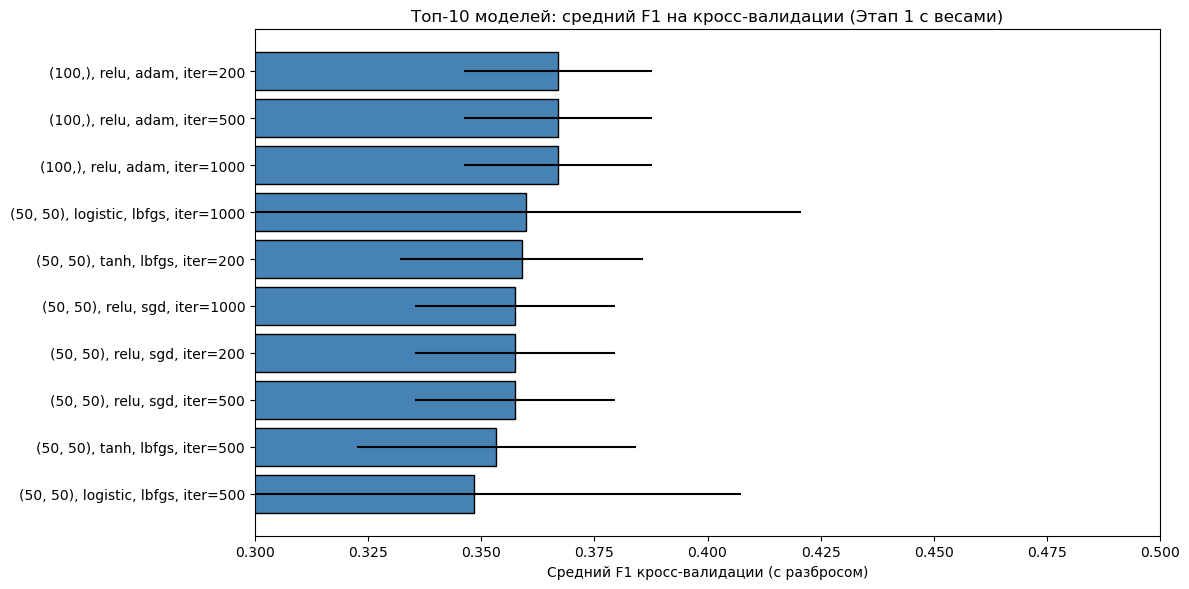

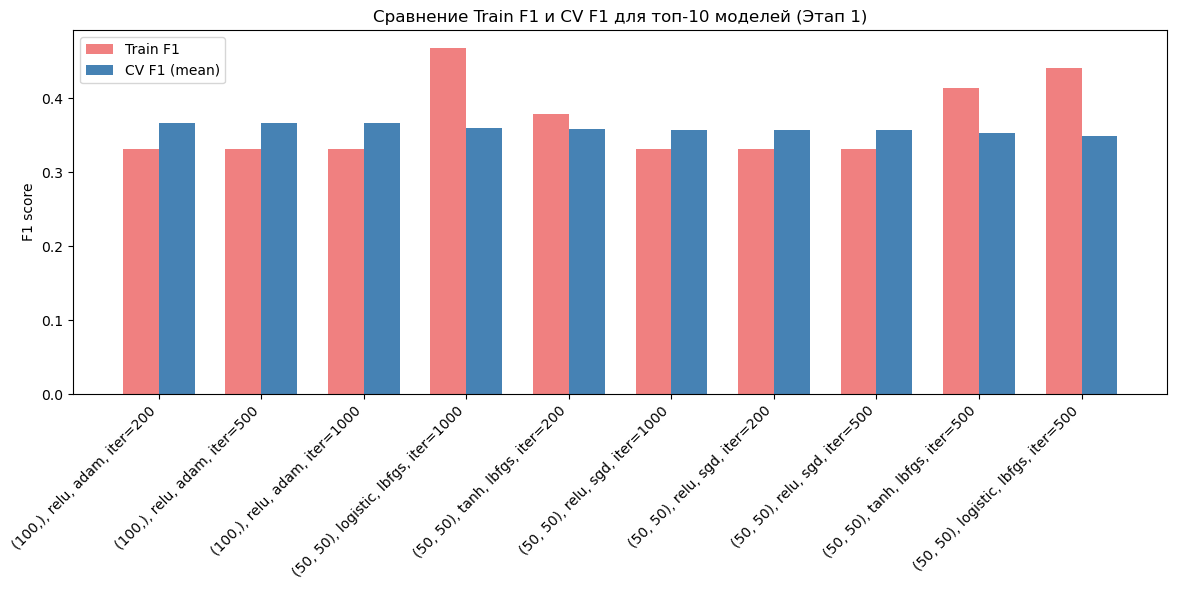

In [43]:
import matplotlib.pyplot as plt
import os

# Папка для сохранения
plot_dir = f'{DATA_DIR}\\plots'
os.makedirs(plot_dir, exist_ok=True)

# Берём топ-10 по среднему F1 кросс-валидации
top10 = res_df.sort_values('cv_f1_mean', ascending=False).head(10).copy()

# Читаемая метка
def make_label(row):
    return f"{row['hidden_layers']}, {row['activation']}, {row['solver']}, iter={row['max_iter']}"

top10['label'] = top10.apply(make_label, axis=1)

# 1) Гистограмма среднего F1 на кросс-валидации
plt.figure(figsize=(12, 6))
bars = plt.barh(top10['label'], top10['cv_f1_mean'], xerr=top10['cv_f1_std'],
                color='steelblue', edgecolor='black')
plt.xlabel('Средний F1 кросс-валидации (с разбросом)')
plt.title('Топ-10 моделей: средний F1 на кросс-валидации (Этап 1 с весами)')
plt.xlim(0.3, 0.5)                     # подстроено под фактический диапазон
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage1_cv_f1.png', dpi=150)
plt.show()

# 2) Сравнение train_f1 и cv_f1_mean
plt.figure(figsize=(12, 6))
x = range(len(top10))
width = 0.35
plt.bar([p - width/2 for p in x], top10['train_f1'], width, label='Train F1', color='lightcoral')
plt.bar([p + width/2 for p in x], top10['cv_f1_mean'], width, label='CV F1 (mean)', color='steelblue')
plt.xticks(x, top10['label'], rotation=45, ha='right')
plt.ylabel('F1 score')
plt.title('Сравнение Train F1 и CV F1 для топ-10 моделей (Этап 1)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage1_f1_comparison.png', dpi=150)
plt.show()

# 2. Обучение на сортированных данных

Размер X_sort: (176, 12)
Распределение классов:
 Type
0    141
1     35
Name: count, dtype: int64
(100,), relu, adam, iter=200 -> CV F1=0.302±0.019, train F1=0.331
(100,), relu, adam, iter=500 -> CV F1=0.302±0.019, train F1=0.331
(100,), relu, adam, iter=1000 -> CV F1=0.302±0.019, train F1=0.331


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3

(50, 50), logistic, lbfgs, iter=1000 -> CV F1=0.366±0.088, train F1=0.448


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib

(50, 50), tanh, lbfgs, iter=200 -> CV F1=0.327±0.025, train F1=0.379
(50, 50), relu, sgd, iter=1000 -> CV F1=0.353±0.011, train F1=0.332
(50, 50), relu, sgd, iter=200 -> CV F1=0.353±0.011, train F1=0.332
(50, 50), relu, sgd, iter=500 -> CV F1=0.353±0.011, train F1=0.332


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib

(50, 50), tanh, lbfgs, iter=500 -> CV F1=0.307±0.015, train F1=0.379


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib

(50, 50), logistic, lbfgs, iter=500 -> CV F1=0.376±0.043, train F1=0.446

=== Лучшая модель на сортированных данных ===
Параметры: hidden=(50, 50), activation=logistic, solver=lbfgs, max_iter=500
CV F1: 0.376 ± 0.043
Train Accuracy: 0.591, Train F1: 0.446


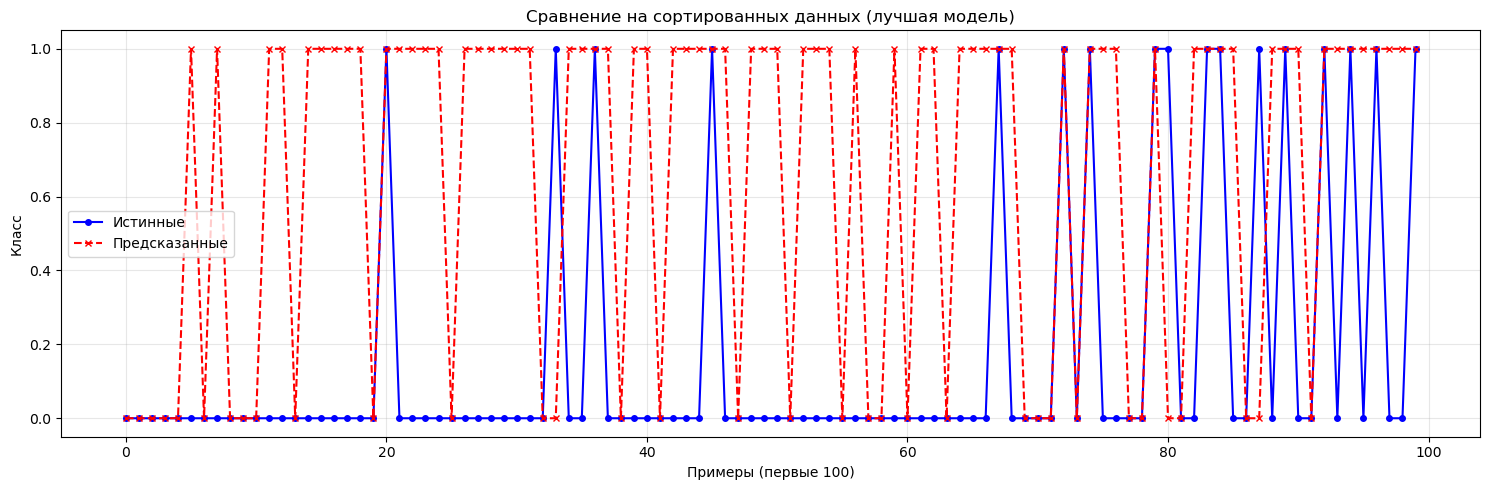


Classification report (сортированные данные):
              precision    recall  f1-score   support

     Класс 0       0.93      0.53      0.68       141
     Класс 1       0.31      0.83      0.45        35

    accuracy                           0.59       176
   macro avg       0.62      0.68      0.56       176
weighted avg       0.80      0.59      0.63       176



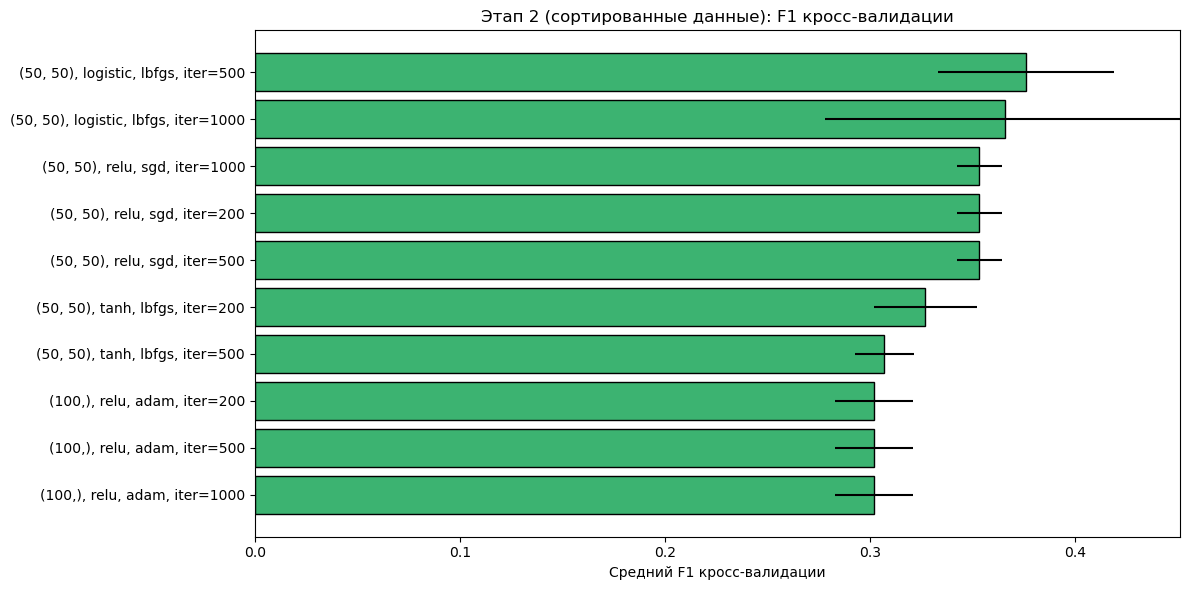

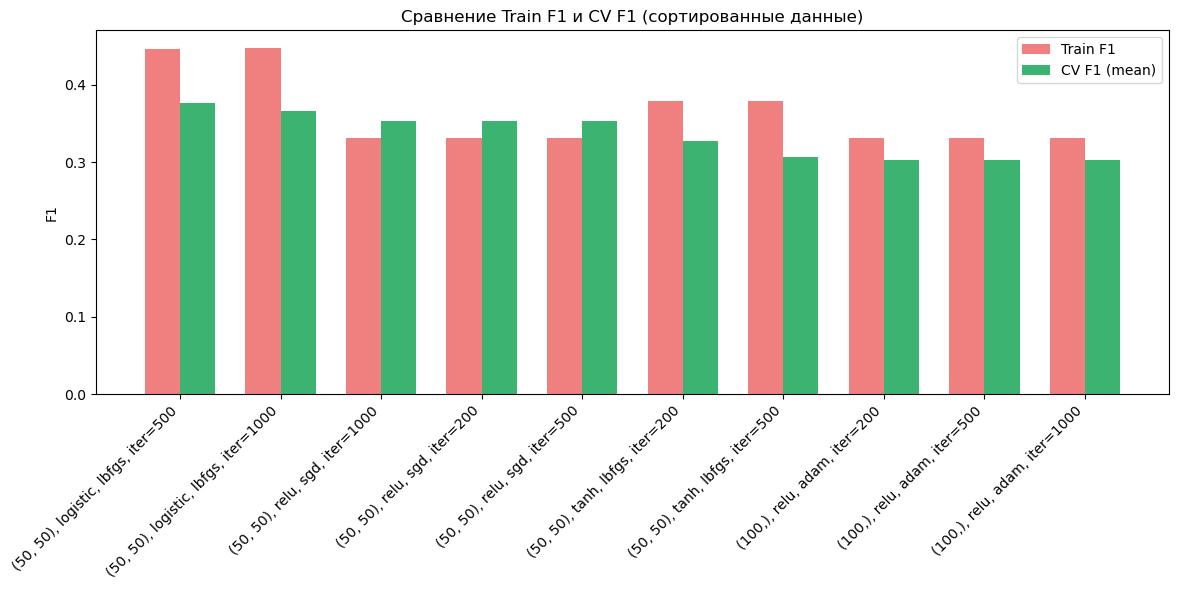

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report
import os

# ---ыы---------------------------------------------------------
# Загрузка и сортировка данных
# ------------------------------------------------------------
DATA_DIR = r'C:\Users\User\TPU\MethodsAI\MethodsAI_lab3'
data = pd.read_excel(f'{DATA_DIR}\\Data_Set_(A+B).xlsx')
data_sorted = data.sort_values(by=['I1', 'I2', 'I3']).reset_index(drop=True)

features_V1 = ['N1','N2','N3','I1','I2','I3','gx','gy','gz','ax','ay','az']
X_sort = data_sorted[features_V1].copy()
Y_sort = (data_sorted['Type'] == 1).astype(int)

print("Размер X_sort:", X_sort.shape)
print("Распределение классов:\n", Y_sort.value_counts())

# ------------------------------------------------------------
# Топ-10 моделей из Этапа 1 (по cv_f1_mean)
# ------------------------------------------------------------
top10 = res_df.sort_values('cv_f1_mean', ascending=False).head(10)

RANDOM_STATE = 42
cv_folds = 3
results_sort = []

for _, row in top10.iterrows():
    hidden = row['hidden_layers']
    activation = row['activation']
    solver = row['solver']
    max_iter = int(row['max_iter'])
    
    # Ручная кросс-валидация с весами
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    cv_f1_scores = []
    
    for train_idx, val_idx in skf.split(X_sort, Y_sort):
        X_train_fold = X_sort.iloc[train_idx]
        X_val_fold = X_sort.iloc[val_idx]
        Y_train_fold = Y_sort.iloc[train_idx]
        Y_val_fold = Y_sort.iloc[val_idx]
        
        # Веса для обучающей части фолда
        class_counts = np.bincount(Y_train_fold)
        class_weights = {0: 1.0 / class_counts[0], 1: 1.0 / class_counts[1]}
        sample_weights = Y_train_fold.map(class_weights).values
        
        mlp = MLPClassifier(
            hidden_layer_sizes=hidden,
            activation=activation,
            solver=solver,
            max_iter=max_iter,
            random_state=RANDOM_STATE,
            early_stopping=False
        )
        mlp.fit(X_train_fold, Y_train_fold, sample_weight=sample_weights)
        Y_pred_val = mlp.predict(X_val_fold)
        f1 = f1_score(Y_val_fold, Y_pred_val, pos_label=1, zero_division=0)
        cv_f1_scores.append(f1)
    
    cv_f1_mean = np.mean(cv_f1_scores)
    cv_f1_std = np.std(cv_f1_scores)
    
    # Обучение на всей сортированной выборке с весами
    class_counts_all = np.bincount(Y_sort)
    class_weights_all = {0: 1.0 / class_counts_all[0], 1: 1.0 / class_counts_all[1]}
    sample_weights_all = Y_sort.map(class_weights_all).values
    
    mlp_all = MLPClassifier(
        hidden_layer_sizes=hidden,
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        random_state=RANDOM_STATE,
        early_stopping=False
    )
    mlp_all.fit(X_sort, Y_sort, sample_weight=sample_weights_all)
    y_pred_all = mlp_all.predict(X_sort)
    acc = accuracy_score(Y_sort, y_pred_all)
    f1 = f1_score(Y_sort, y_pred_all, pos_label=1, zero_division=0)
    
    results_sort.append({
        'hidden_layers': hidden,
        'activation': activation,
        'solver': solver,
        'max_iter': max_iter,
        'cv_f1_mean': cv_f1_mean,
        'cv_f1_std': cv_f1_std,
        'train_accuracy': acc,
        'train_f1': f1,
        'model': mlp_all
    })
    print(f"{hidden}, {activation}, {solver}, iter={max_iter} -> "
          f"CV F1={cv_f1_mean:.3f}±{cv_f1_std:.3f}, train F1={f1:.3f}")

# ------------------------------------------------------------
# Лучшая модель по среднему F1 кросс-валидации
# ------------------------------------------------------------
res_sort_df = pd.DataFrame(results_sort)
best = res_sort_df.loc[res_sort_df['cv_f1_mean'].idxmax()]
print("\n=== Лучшая модель на сортированных данных ===")
print(f"Параметры: hidden={best['hidden_layers']}, activation={best['activation']}, "
      f"solver={best['solver']}, max_iter={best['max_iter']}")
print(f"CV F1: {best['cv_f1_mean']:.3f} ± {best['cv_f1_std']:.3f}")
print(f"Train Accuracy: {best['train_accuracy']:.3f}, Train F1: {best['train_f1']:.3f}")

# ------------------------------------------------------------
# График сравнения (первые 100 точек) для лучшей модели
# ------------------------------------------------------------
best_model = best['model']
y_pred_plot = best_model.predict(X_sort)

plt.figure(figsize=(15, 5))
plt.plot(Y_sort.values[:100], 'bo-', label='Истинные', markersize=4)
plt.plot(y_pred_plot[:100], 'rx--', label='Предсказанные', markersize=4)
plt.xlabel('Примеры (первые 100)')
plt.ylabel('Класс')
plt.title('Сравнение на сортированных данных (лучшая модель)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plot_dir = f'{DATA_DIR}\\plots'
os.makedirs(plot_dir, exist_ok=True)
plt.savefig(f'{plot_dir}\\stage2_predictions.png', dpi=150)
plt.show()

print("\nClassification report (сортированные данные):")
print(classification_report(Y_sort, y_pred_plot, target_names=['Класс 0', 'Класс 1'], zero_division=0))

# ------------------------------------------------------------
# Визуализация топ-10 на сортированных данных
# ------------------------------------------------------------
top_sort = res_sort_df.sort_values('cv_f1_mean', ascending=False).head(10).copy()

def make_label_sort(row):
    return f"{row['hidden_layers']}, {row['activation']}, {row['solver']}, iter={row['max_iter']}"

top_sort['label'] = top_sort.apply(make_label_sort, axis=1)

# 1) Гистограмма F1 кросс-валидации
plt.figure(figsize=(12, 6))
plt.barh(top_sort['label'], top_sort['cv_f1_mean'], xerr=top_sort['cv_f1_std'], 
         color='mediumseagreen', edgecolor='black')
plt.xlabel('Средний F1 кросс-валидации')
plt.title('Этап 2 (сортированные данные): F1 кросс-валидации')
plt.xlim(0, max(top_sort['cv_f1_mean']) * 1.2)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage2_cv_f1.png', dpi=150)
plt.show()

# 2) Сравнение train_f1 и cv_f1_mean
plt.figure(figsize=(12, 6))
x = range(len(top_sort))
width = 0.35
plt.bar([p - width/2 for p in x], top_sort['train_f1'], width, label='Train F1', color='lightcoral')
plt.bar([p + width/2 for p in x], top_sort['cv_f1_mean'], width, label='CV F1 (mean)', color='mediumseagreen')
plt.xticks(x, top_sort['label'], rotation=45, ha='right')
plt.ylabel('F1')
plt.title('Сравнение Train F1 и CV F1 (сортированные данные)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage2_f1_comparison.png', dpi=150)
plt.show()

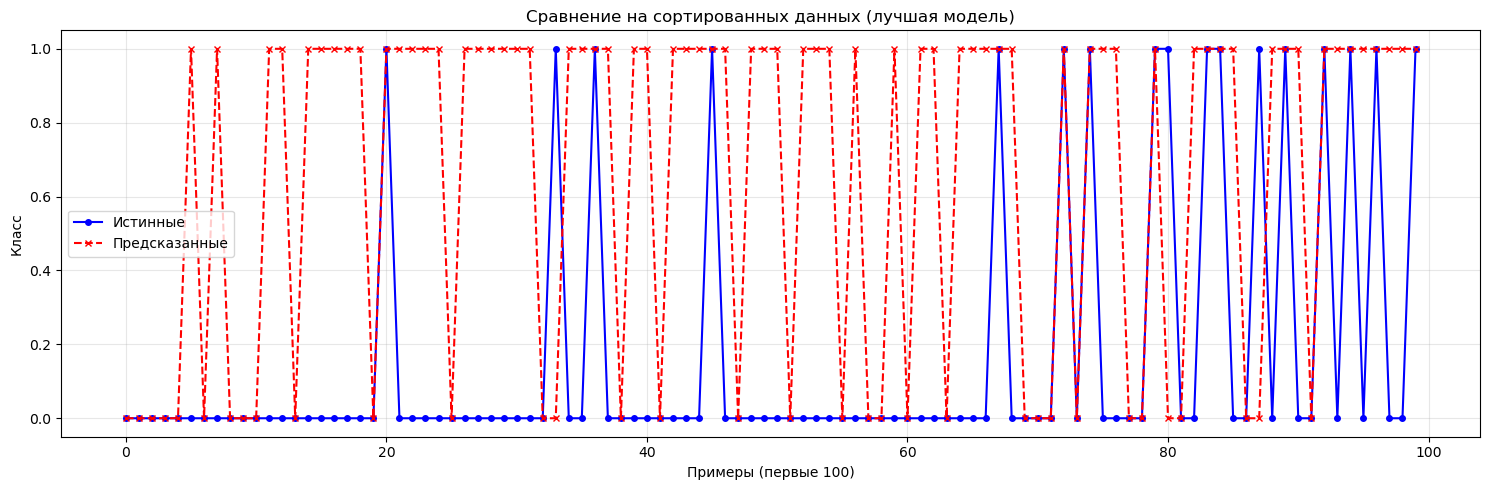

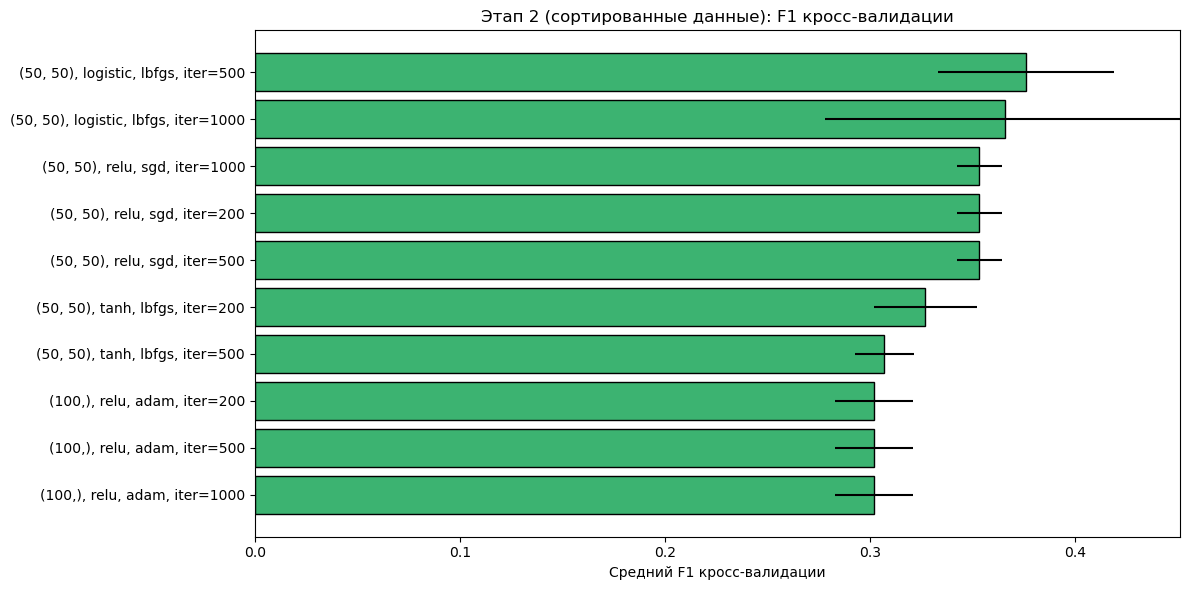

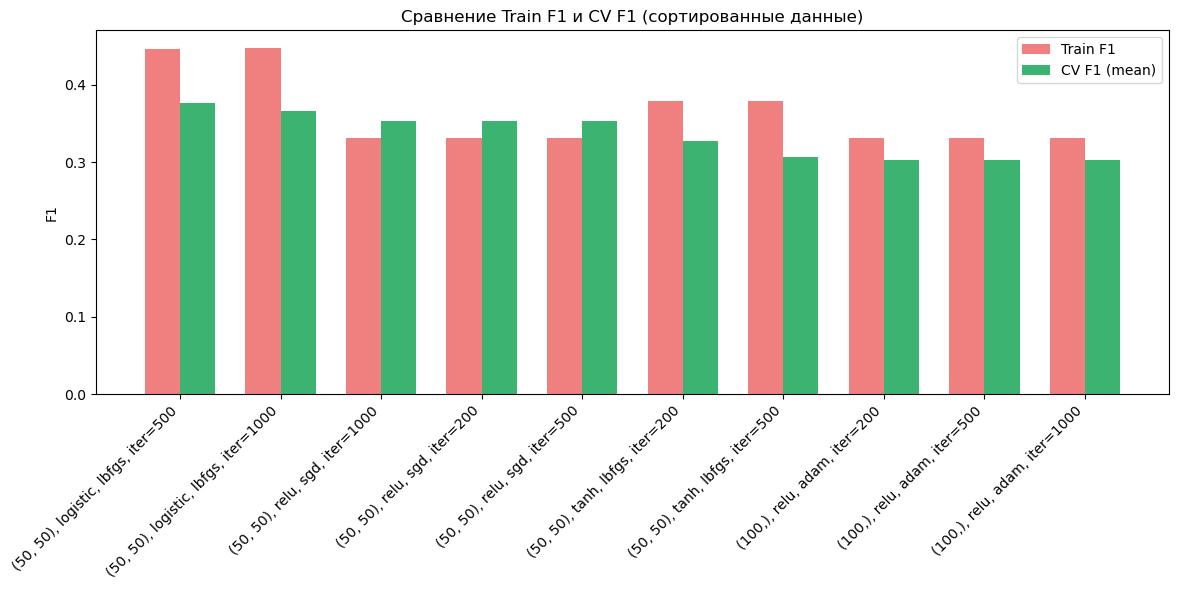

In [45]:
import os
import matplotlib.pyplot as plt

plot_dir = f'{DATA_DIR}\\plots'
os.makedirs(plot_dir, exist_ok=True)

# График сравнения для лучшей модели (уже есть best_model и y_pred_plot)
plt.figure(figsize=(15, 5))
plt.plot(Y_sort.values[:100], 'bo-', label='Истинные', markersize=4)
plt.plot(y_pred_plot[:100], 'rx--', label='Предсказанные', markersize=4)
plt.xlabel('Примеры (первые 100)')
plt.ylabel('Класс')
plt.title('Сравнение на сортированных данных (лучшая модель)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage2_predictions.png', dpi=150)
plt.show()

# Топ-10 по сортированным данным (используем cv_f1_mean)
res_sort_df = pd.DataFrame(results_sort)
top_sort = res_sort_df.sort_values('cv_f1_mean', ascending=False).head(10).copy()

def make_label_sort(row):
    return f"{row['hidden_layers']}, {row['activation']}, {row['solver']}, iter={row['max_iter']}"

top_sort['label'] = top_sort.apply(make_label_sort, axis=1)

# 1) Гистограмма F1 кросс-валидации
plt.figure(figsize=(12, 6))
plt.barh(top_sort['label'], top_sort['cv_f1_mean'], xerr=top_sort['cv_f1_std'], 
         color='mediumseagreen', edgecolor='black')
plt.xlabel('Средний F1 кросс-валидации')
plt.title('Этап 2 (сортированные данные): F1 кросс-валидации')
plt.xlim(0, max(top_sort['cv_f1_mean']) * 1.2)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage2_cv_f1.png', dpi=150)
plt.show()

# 2) Сравнение train_f1 и cv_f1_mean
plt.figure(figsize=(12, 6))
x = range(len(top_sort))
width = 0.35
plt.bar([p - width/2 for p in x], top_sort['train_f1'], width, label='Train F1', color='lightcoral')
plt.bar([p + width/2 for p in x], top_sort['cv_f1_mean'], width, label='CV F1 (mean)', color='mediumseagreen')
plt.xticks(x, top_sort['label'], rotation=45, ha='right')
plt.ylabel('F1')
plt.title('Сравнение Train F1 и CV F1 (сортированные данные)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage2_f1_comparison.png', dpi=150)
plt.show()

# 3. Обучение на нормализованных данных

Максимальный CV F1 (Этап 1, без сортировки): 0.3670
Максимальный CV F1 (Этап 2, сортировка):       0.3761

Выбран СОРТИРОВАННЫЙ датасет (Этап 2).
Форма X_norm: (176, 12)


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multi

(100,), relu, adam, iter=200 -> CV F1=0.375±0.064, train F1=0.624


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


(100,), relu, adam, iter=500 -> CV F1=0.594±0.142, train F1=0.773


...

(50, 50), tanh, lbfgs, iter=200 -> CV F1=0.683±0.053, train F1=1.000
(50, 50), relu, sgd, iter=1000 -> CV F1=0.348±0.007, train F1=0.348
(50, 50), relu, sgd, iter=200 -> CV F1=0.348±0.007, train F1=0.348
(50, 50), relu, sgd, iter=500 -> CV F1=0.348±0.007, train F1=0.348


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib

(50, 50), tanh, lbfgs, iter=500 -> CV F1=0.645±0.104, train F1=1.000


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib

(50, 50), logistic, lbfgs, iter=500 -> CV F1=0.647±0.103, train F1=1.000

=== Лучшая модель на нормализованных данных ===
Параметры: hidden=(100,), activation=relu, solver=adam, max_iter=1000
CV F1: 0.694 ± 0.132
Train Accuracy: 0.960, Train F1: 0.909


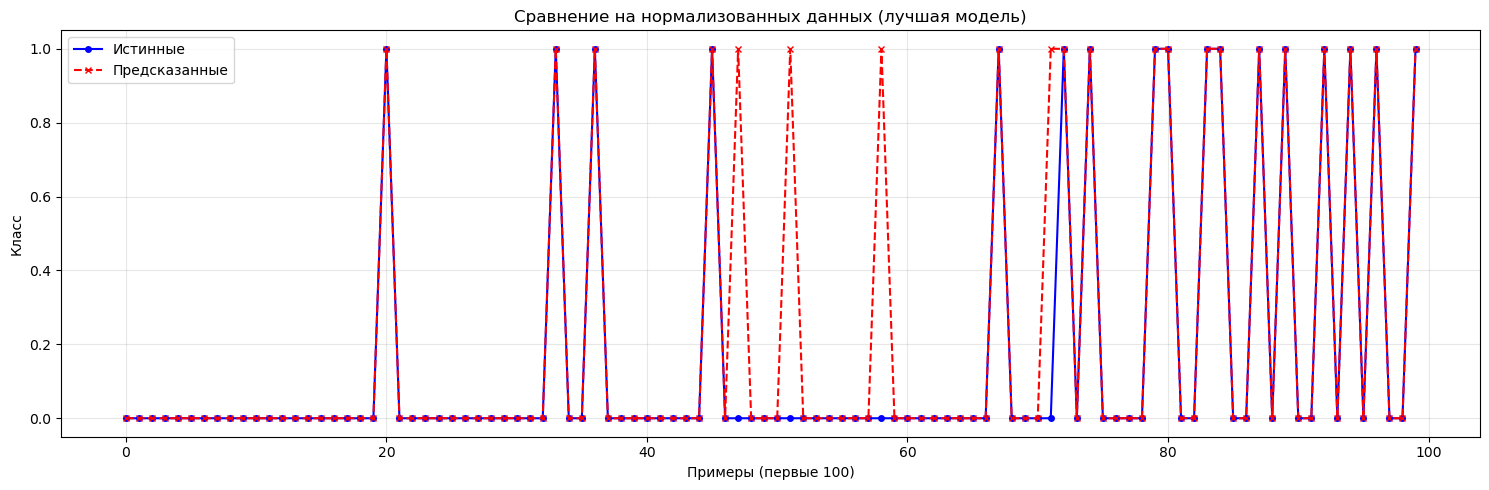


Classification report (нормализованные данные):
              precision    recall  f1-score   support

     Класс 0       1.00      0.95      0.97       141
     Класс 1       0.83      1.00      0.91        35

    accuracy                           0.96       176
   macro avg       0.92      0.98      0.94       176
weighted avg       0.97      0.96      0.96       176



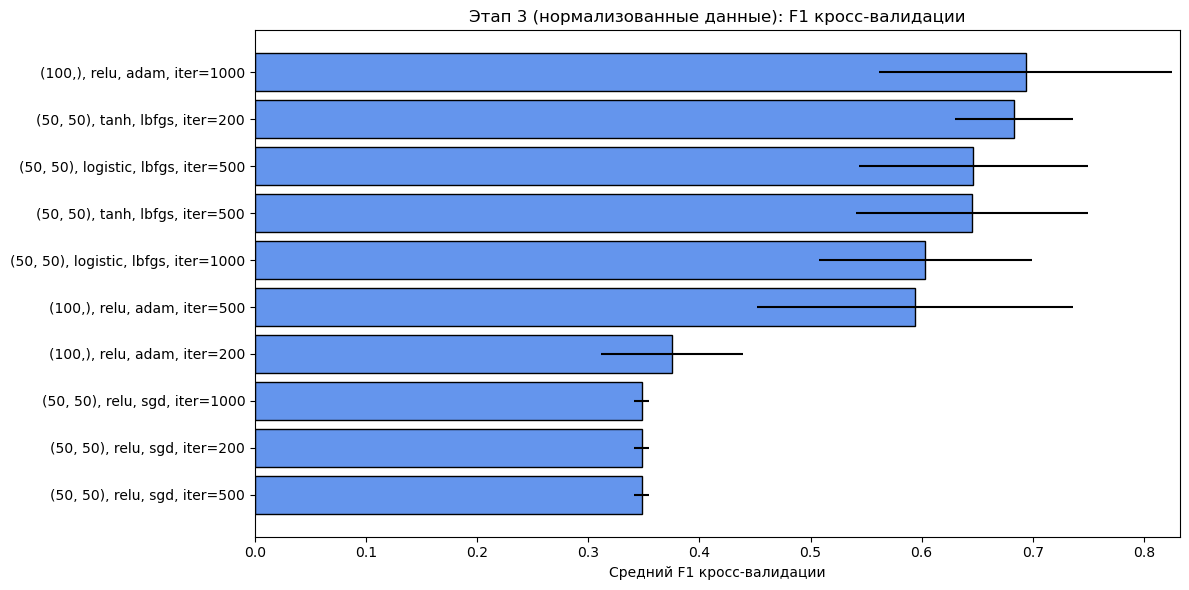

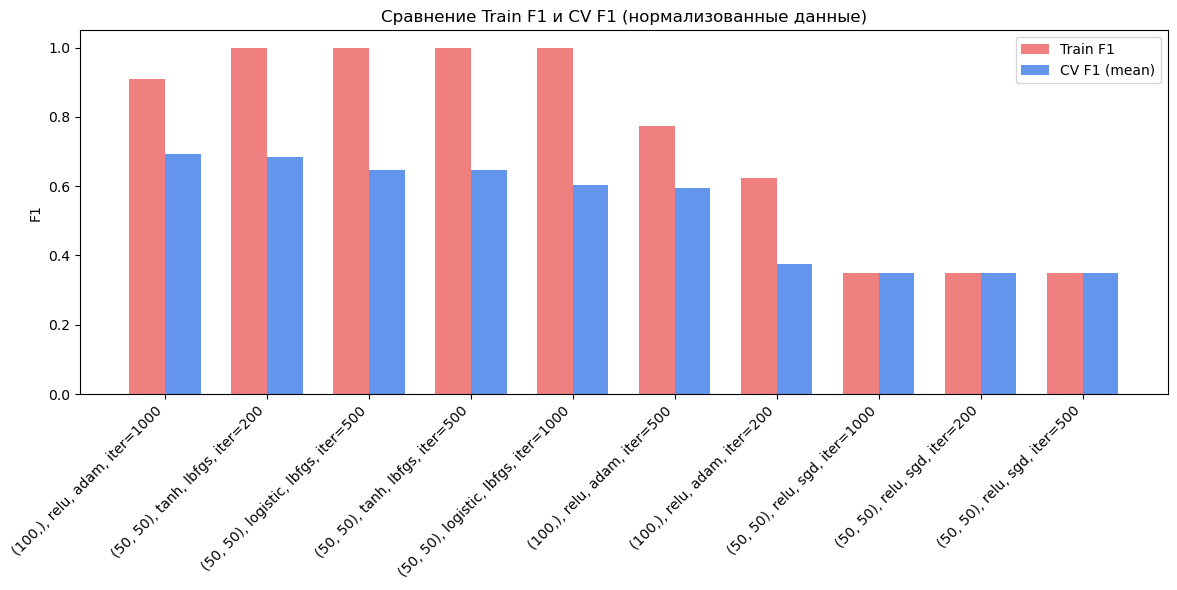

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import MinMaxScaler
import os

# ------------------------------------------------------------
# 1. Сравнение Этапов 1 и 2 по максимальному cv_f1_mean
# ------------------------------------------------------------
best_f1_stage1 = res_df['cv_f1_mean'].max()
best_f1_stage2 = res_sort_df['cv_f1_mean'].max()

print(f"Максимальный CV F1 (Этап 1, без сортировки): {best_f1_stage1:.4f}")
print(f"Максимальный CV F1 (Этап 2, сортировка):       {best_f1_stage2:.4f}")

if best_f1_stage1 >= best_f1_stage2:
    print("\nВыбран датасет БЕЗ сортировки (Этап 1).")
    X_base = X.copy()
    Y_base = Y.copy()
else:
    print("\nВыбран СОРТИРОВАННЫЙ датасет (Этап 2).")
    X_base = X_sort.copy()
    Y_base = Y_sort.copy()

# ------------------------------------------------------------
# 2. Нормализация
# ------------------------------------------------------------
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X_base)
print("Форма X_norm:", X_norm.shape)

# ------------------------------------------------------------
# 3. Эксперименты с нормализованными данными (топ-10 конфигураций из Этапа 1)
# ------------------------------------------------------------
top10_configs = res_df.sort_values('cv_f1_mean', ascending=False).head(10)

RANDOM_STATE = 42
cv_folds = 3
results_norm = []

for _, row in top10_configs.iterrows():
    hidden = row['hidden_layers']
    activation = row['activation']
    solver = row['solver']
    max_iter = int(row['max_iter'])
    
    # Ручная кросс-валидация с весами
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    cv_f1_scores = []
    
    for train_idx, val_idx in skf.split(X_norm, Y_base):
        X_tr = X_norm[train_idx]
        X_val = X_norm[val_idx]
        Y_tr = Y_base.iloc[train_idx]
        Y_val = Y_base.iloc[val_idx]
        
        class_counts = np.bincount(Y_tr)
        class_weights = {0: 1.0 / class_counts[0], 1: 1.0 / class_counts[1]}
        sample_weights = Y_tr.map(class_weights).values
        
        mlp = MLPClassifier(
            hidden_layer_sizes=hidden,
            activation=activation,
            solver=solver,
            max_iter=max_iter,
            random_state=RANDOM_STATE,
            early_stopping=False
        )
        mlp.fit(X_tr, Y_tr, sample_weight=sample_weights)
        Y_pred_val = mlp.predict(X_val)
        f1 = f1_score(Y_val, Y_pred_val, pos_label=1, zero_division=0)
        cv_f1_scores.append(f1)
    
    cv_f1_mean = np.mean(cv_f1_scores)
    cv_f1_std = np.std(cv_f1_scores)
    
    # Обучение на всей нормализованной выборке с весами
    class_counts_all = np.bincount(Y_base)
    class_weights_all = {0: 1.0 / class_counts_all[0], 1: 1.0 / class_counts_all[1]}
    sample_weights_all = Y_base.map(class_weights_all).values
    
    mlp_all = MLPClassifier(
        hidden_layer_sizes=hidden,
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        random_state=RANDOM_STATE,
        early_stopping=False
    )
    mlp_all.fit(X_norm, Y_base, sample_weight=sample_weights_all)
    y_pred_all = mlp_all.predict(X_norm)
    acc = accuracy_score(Y_base, y_pred_all)
    f1 = f1_score(Y_base, y_pred_all, pos_label=1, zero_division=0)
    
    results_norm.append({
        'hidden_layers': hidden,
        'activation': activation,
        'solver': solver,
        'max_iter': max_iter,
        'cv_f1_mean': cv_f1_mean,
        'cv_f1_std': cv_f1_std,
        'train_accuracy': acc,
        'train_f1': f1,
        'model': mlp_all
    })
    print(f"{hidden}, {activation}, {solver}, iter={max_iter} -> "
          f"CV F1={cv_f1_mean:.3f}±{cv_f1_std:.3f}, train F1={f1:.3f}")

# ------------------------------------------------------------
# 4. Лучшая модель по CV F1
# ------------------------------------------------------------
res_norm_df = pd.DataFrame(results_norm)
best_norm = res_norm_df.loc[res_norm_df['cv_f1_mean'].idxmax()]

print("\n=== Лучшая модель на нормализованных данных ===")
print(f"Параметры: hidden={best_norm['hidden_layers']}, activation={best_norm['activation']}, "
      f"solver={best_norm['solver']}, max_iter={best_norm['max_iter']}")
print(f"CV F1: {best_norm['cv_f1_mean']:.3f} ± {best_norm['cv_f1_std']:.3f}")
print(f"Train Accuracy: {best_norm['train_accuracy']:.3f}, Train F1: {best_norm['train_f1']:.3f}")

# ------------------------------------------------------------
# 5. График сравнения для лучшей модели
# ------------------------------------------------------------
best_model_norm = best_norm['model']
y_pred_norm = best_model_norm.predict(X_norm)

plot_dir = f'{DATA_DIR}\\plots'
os.makedirs(plot_dir, exist_ok=True)

plt.figure(figsize=(15, 5))
plt.plot(Y_base.values[:100], 'bo-', label='Истинные', markersize=4)
plt.plot(y_pred_norm[:100], 'rx--', label='Предсказанные', markersize=4)
plt.xlabel('Примеры (первые 100)')
plt.ylabel('Класс')
plt.title('Сравнение на нормализованных данных (лучшая модель)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage3_predictions.png', dpi=150)
plt.show()

print("\nClassification report (нормализованные данные):")
print(classification_report(Y_base, y_pred_norm, target_names=['Класс 0', 'Класс 1'], zero_division=0))

# ------------------------------------------------------------
# 6. Визуализация топ-10 на нормализованных данных
# ------------------------------------------------------------
top_norm_vis = res_norm_df.sort_values('cv_f1_mean', ascending=False).head(10).copy()

def make_label_norm(row):
    return f"{row['hidden_layers']}, {row['activation']}, {row['solver']}, iter={row['max_iter']}"

top_norm_vis['label'] = top_norm_vis.apply(make_label_norm, axis=1)

# Гистограмма F1 кросс-валидации
plt.figure(figsize=(12, 6))
plt.barh(top_norm_vis['label'], top_norm_vis['cv_f1_mean'], xerr=top_norm_vis['cv_f1_std'], 
         color='cornflowerblue', edgecolor='black')
plt.xlabel('Средний F1 кросс-валидации')
plt.title('Этап 3 (нормализованные данные): F1 кросс-валидации')
plt.xlim(0, max(top_norm_vis['cv_f1_mean']) * 1.2)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage3_cv_f1.png', dpi=150)
plt.show()

# Сравнение train_f1 и cv_f1_mean
plt.figure(figsize=(12, 6))
x = range(len(top_norm_vis))
width = 0.35
plt.bar([p - width/2 for p in x], top_norm_vis['train_f1'], width, label='Train F1', color='lightcoral')
plt.bar([p + width/2 for p in x], top_norm_vis['cv_f1_mean'], width, label='CV F1 (mean)', color='cornflowerblue')
plt.xticks(x, top_norm_vis['label'], rotation=45, ha='right')
plt.ylabel('F1')
plt.title('Сравнение Train F1 и CV F1 (нормализованные данные)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage3_f1_comparison.png', dpi=150)
plt.show()

# 4. Обучение на сбалансированных данных

БАЛАНСИРОВКА SMOTE
Размер после SMOTE: (282, 12), распределение: [141 141]


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


(100,), relu, adam, iter=1000 -> CV F1=0.784±0.092, train F1=0.940


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib

(50, 50), tanh, lbfgs, iter=200 -> CV F1=0.780±0.077, train F1=1.000


...

(100,), relu, adam, iter=1000 -> CV F1=0.777±0.080, train F1=0.943


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


(50, 50), tanh, lbfgs, iter=200 -> CV F1=0.805±0.108, train F1=1.000


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


(50, 50), logistic, lbfgs, iter=500 -> CV F1=0.787±0.083, train F1=1.000
(50, 50), tanh, lbfgs, iter=500 -> CV F1=0.805±0.108, train F1=1.000
(50, 50), logistic, lbfgs, iter=1000 -> CV F1=0.787±0.083, train F1=1.000

Лучшая модель (ADASYN):
Параметры: hidden=(50, 50), activation=tanh, solver=lbfgs, max_iter=200
CV F1: 0.805 ± 0.108
Train Accuracy: 1.000, Train F1: 1.000

Classification report (SMOTE, лучшая модель):
              precision    recall  f1-score   support

     Класс 0       1.00      1.00      1.00       141
     Класс 1       1.00      1.00      1.00       141

    accuracy                           1.00       282
   macro avg       1.00      1.00      1.00       282
weighted avg       1.00      1.00      1.00       282



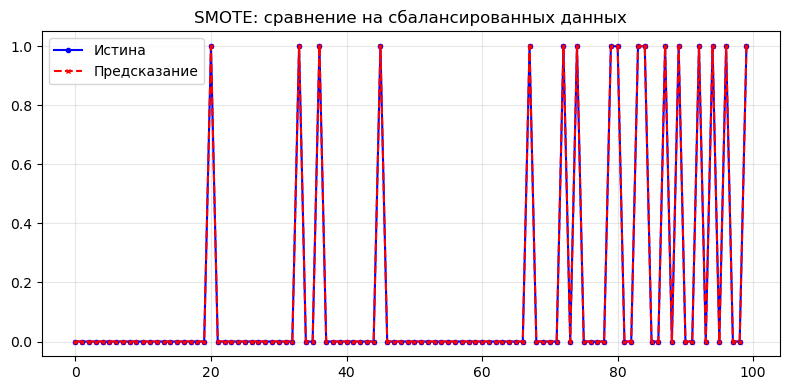


Classification report (ADASYN, лучшая модель):
              precision    recall  f1-score   support

     Класс 0       1.00      1.00      1.00       141
     Класс 1       1.00      1.00      1.00       140

    accuracy                           1.00       281
   macro avg       1.00      1.00      1.00       281
weighted avg       1.00      1.00      1.00       281



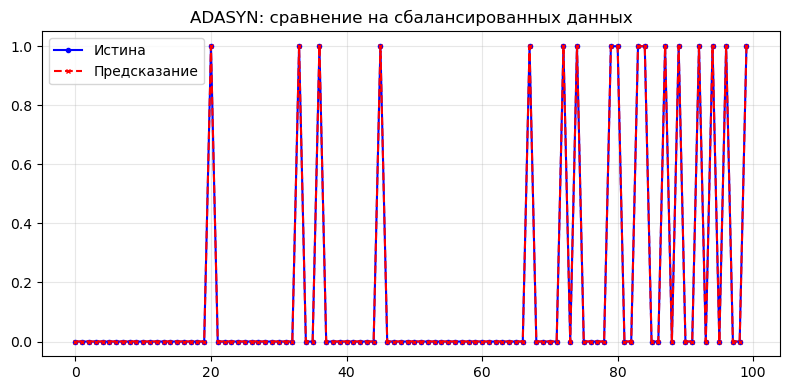

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE, ADASYN
import os

# ------------------------------------------------------------
# 0. Исходные нормализованные данные (из Этапа 3)
# ------------------------------------------------------------
# X_norm и Y_base должны быть доступны из предыдущего этапа

# ------------------------------------------------------------
# 1. Выбор конфигураций (топ-5 по cv_f1_mean из Этапа 3)
# ------------------------------------------------------------
top5_configs = res_norm_df.sort_values('cv_f1_mean', ascending=False).head(5)

RANDOM_STATE = 42
cv_folds = 3

# ------------------------------------------------------------
# 2. SMOTE
# ------------------------------------------------------------
print("=" * 60)
print("БАЛАНСИРОВКА SMOTE")
print("=" * 60)

smote = SMOTE(random_state=RANDOM_STATE)
X_smote, Y_smote = smote.fit_resample(X_norm, Y_base)
print(f"Размер после SMOTE: {X_smote.shape}, распределение: {np.bincount(Y_smote)}")

results_smote = []
for _, row in top5_configs.iterrows():
    hidden = row['hidden_layers']
    activation = row['activation']
    solver = row['solver']
    max_iter = int(row['max_iter'])
    
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden,
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        random_state=RANDOM_STATE,
        early_stopping=False
    )
    cv_scores = cross_val_score(mlp, X_smote, Y_smote, cv=cv_folds, scoring='f1')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    mlp.fit(X_smote, Y_smote)
    y_pred = mlp.predict(X_smote)
    acc = accuracy_score(Y_smote, y_pred)
    f1 = f1_score(Y_smote, y_pred, pos_label=1)
    
    results_smote.append({
        'hidden_layers': hidden, 'activation': activation,
        'solver': solver, 'max_iter': max_iter,
        'cv_f1_mean': cv_mean, 'cv_f1_std': cv_std,
        'train_accuracy': acc, 'train_f1': f1, 'model': mlp
    })
    print(f"{hidden}, {activation}, {solver}, iter={max_iter} -> CV F1={cv_mean:.3f}±{cv_std:.3f}, train F1={f1:.3f}")

res_smote_df = pd.DataFrame(results_smote)
best_smote = res_smote_df.loc[res_smote_df['cv_f1_mean'].idxmax()]
print("\nЛучшая модель (SMOTE):")
print(f"Параметры: hidden={best_smote['hidden_layers']}, activation={best_smote['activation']}, "
      f"solver={best_smote['solver']}, max_iter={best_smote['max_iter']}")
print(f"CV F1: {best_smote['cv_f1_mean']:.3f} ± {best_smote['cv_f1_std']:.3f}")
print(f"Train Accuracy: {best_smote['train_accuracy']:.3f}, Train F1: {best_smote['train_f1']:.3f}")

# ------------------------------------------------------------
# 3. ADASYN
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("БАЛАНСИРОВКА ADASYN")
print("=" * 60)

adasyn = ADASYN(random_state=RANDOM_STATE)
X_adasyn, Y_adasyn = adasyn.fit_resample(X_norm, Y_base)
print(f"Размер после ADASYN: {X_adasyn.shape}, распределение: {np.bincount(Y_adasyn)}")

results_adasyn = []
for _, row in top5_configs.iterrows():
    hidden = row['hidden_layers']
    activation = row['activation']
    solver = row['solver']
    max_iter = int(row['max_iter'])
    
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden,
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        random_state=RANDOM_STATE,
        early_stopping=False
    )
    cv_scores = cross_val_score(mlp, X_adasyn, Y_adasyn, cv=cv_folds, scoring='f1')
    cv_mean = cv_scores.mean()
    cv_std = cv_scores.std()
    
    mlp.fit(X_adasyn, Y_adasyn)
    y_pred = mlp.predict(X_adasyn)
    acc = accuracy_score(Y_adasyn, y_pred)
    f1 = f1_score(Y_adasyn, y_pred, pos_label=1)
    
    results_adasyn.append({
        'hidden_layers': hidden, 'activation': activation,
        'solver': solver, 'max_iter': max_iter,
        'cv_f1_mean': cv_mean, 'cv_f1_std': cv_std,
        'train_accuracy': acc, 'train_f1': f1, 'model': mlp
    })
    print(f"{hidden}, {activation}, {solver}, iter={max_iter} -> CV F1={cv_mean:.3f}±{cv_std:.3f}, train F1={f1:.3f}")

res_adasyn_df = pd.DataFrame(results_adasyn)
best_adasyn = res_adasyn_df.loc[res_adasyn_df['cv_f1_mean'].idxmax()]
print("\nЛучшая модель (ADASYN):")
print(f"Параметры: hidden={best_adasyn['hidden_layers']}, activation={best_adasyn['activation']}, "
      f"solver={best_adasyn['solver']}, max_iter={best_adasyn['max_iter']}")
print(f"CV F1: {best_adasyn['cv_f1_mean']:.3f} ± {best_adasyn['cv_f1_std']:.3f}")
print(f"Train Accuracy: {best_adasyn['train_accuracy']:.3f}, Train F1: {best_adasyn['train_f1']:.3f}")

# ------------------------------------------------------------
# 4. Отчёты классификации и графики
# ------------------------------------------------------------
plot_dir = f'{DATA_DIR}\\plots'
os.makedirs(plot_dir, exist_ok=True)

# SMOTE отчёт и график
best_model_smote = best_smote['model']
y_pred_smote = best_model_smote.predict(X_smote)
print("\nClassification report (SMOTE, лучшая модель):")
print(classification_report(Y_smote, y_pred_smote, target_names=['Класс 0', 'Класс 1']))

plt.figure(figsize=(8, 4))
plt.plot(Y_smote[:100], 'bo-', label='Истина', markersize=3)
plt.plot(y_pred_smote[:100], 'rx--', label='Предсказание', markersize=3)
plt.title('SMOTE: сравнение на сбалансированных данных')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage4_smote_predictions.png', dpi=150)
plt.show()

# ADASYN отчёт и график
best_model_adasyn = best_adasyn['model']
y_pred_adasyn = best_model_adasyn.predict(X_adasyn)
print("\nClassification report (ADASYN, лучшая модель):")
print(classification_report(Y_adasyn, y_pred_adasyn, target_names=['Класс 0', 'Класс 1']))

plt.figure(figsize=(8, 4))
plt.plot(Y_adasyn[:100], 'bo-', label='Истина', markersize=3)
plt.plot(y_pred_adasyn[:100], 'rx--', label='Предсказание', markersize=3)
plt.title('ADASYN: сравнение на сбалансированных данных')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage4_adasyn_predictions.png', dpi=150)
plt.show()

# 5. Финальная проверка на контрольной выборке

Форма X_C: (58, 12)
Распределение классов в С:
 Type
0    47
1    11
Name: count, dtype: int64
=== Проверка модели Этапа 3 (нормализация) ===
Accuracy: 0.914, F1: 0.800

=== Проверка модели SMOTE ===
Accuracy: 0.931, F1: 0.818

=== Проверка модели ADASYN ===
Accuracy: 0.879, F1: 0.667

Лучшая модель на контрольной выборке: SMOTE (F1=0.818)


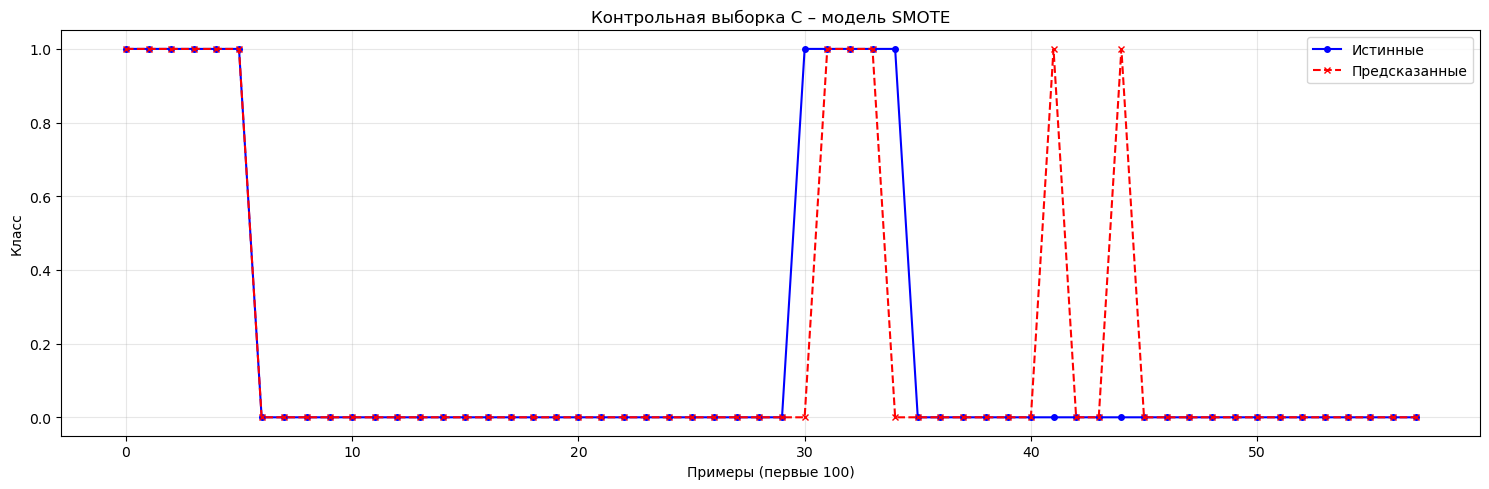


Classification report (выборка C, модель SMOTE):
              precision    recall  f1-score   support

     Класс 0       0.96      0.96      0.96        47
     Класс 1       0.82      0.82      0.82        11

    accuracy                           0.93        58
   macro avg       0.89      0.89      0.89        58
weighted avg       0.93      0.93      0.93        58



In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report
import os

# ------------------------------------------------------------
# 1. Загрузка контрольной выборки С
# ------------------------------------------------------------
DATA_DIR = r'C:\Users\User\TPU\MethodsAI\MethodsAI_lab3'
data_C = pd.read_excel(f'{DATA_DIR}\\Data_Set_C.xlsx')

features_V1 = ['N1','N2','N3','I1','I2','I3','gx','gy','gz','ax','ay','az']
X_C = data_C[features_V1].copy()
Y_C = (data_C['Type'] == 1).astype(int)

print("Форма X_C:", X_C.shape)
print("Распределение классов в С:\n", Y_C.value_counts())

# ------------------------------------------------------------
# 2. Применение того же масштабирования, что и на обучении
# ------------------------------------------------------------
X_C_norm = scaler.transform(X_C)   # scaler из Этапа 3

# ------------------------------------------------------------
# 3. Проверка трёх лучших моделей
# ------------------------------------------------------------
models = {}

# Модель Этапа 3 (нормализация, без балансировки)
print("=== Проверка модели Этапа 3 (нормализация) ===")
y_pred_C = best_norm['model'].predict(X_C_norm)
acc_C = accuracy_score(Y_C, y_pred_C)
f1_C = f1_score(Y_C, y_pred_C, pos_label=1, zero_division=0)
print(f"Accuracy: {acc_C:.3f}, F1: {f1_C:.3f}")
models['Этап 3 (норм.)'] = (y_pred_C, acc_C, f1_C)

# Модель SMOTE
print("\n=== Проверка модели SMOTE ===")
y_pred_C_smote = best_smote['model'].predict(X_C_norm)
acc_C_smote = accuracy_score(Y_C, y_pred_C_smote)
f1_C_smote = f1_score(Y_C, y_pred_C_smote, pos_label=1, zero_division=0)
print(f"Accuracy: {acc_C_smote:.3f}, F1: {f1_C_smote:.3f}")
models['SMOTE'] = (y_pred_C_smote, acc_C_smote, f1_C_smote)

# Модель ADASYN
print("\n=== Проверка модели ADASYN ===")
y_pred_C_adasyn = best_adasyn['model'].predict(X_C_norm)
acc_C_adasyn = accuracy_score(Y_C, y_pred_C_adasyn)
f1_C_adasyn = f1_score(Y_C, y_pred_C_adasyn, pos_label=1, zero_division=0)
print(f"Accuracy: {acc_C_adasyn:.3f}, F1: {f1_C_adasyn:.3f}")
models['ADASYN'] = (y_pred_C_adasyn, acc_C_adasyn, f1_C_adasyn)

# Выбор лучшей модели по F1
best_name = max(models, key=lambda k: models[k][2])
y_pred_best = models[best_name][0]
acc_best = models[best_name][1]
f1_best = models[best_name][2]
print(f"\nЛучшая модель на контрольной выборке: {best_name} (F1={f1_best:.3f})")

# ------------------------------------------------------------
# 4. График сравнения для лучшей модели
# ------------------------------------------------------------
plot_dir = f'{DATA_DIR}\\plots'
os.makedirs(plot_dir, exist_ok=True)

plt.figure(figsize=(15, 5))
plt.plot(Y_C.values[:100], 'bo-', label='Истинные', markersize=4)
plt.plot(y_pred_best[:100], 'rx--', label='Предсказанные', markersize=4)
plt.xlabel('Примеры (первые 100)')
plt.ylabel('Класс')
plt.title(f'Контрольная выборка С – модель {best_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plot_dir}\\stage5_C_predictions.png', dpi=150)
plt.show()

# ------------------------------------------------------------
# 5. Детальный отчёт классификации
# ------------------------------------------------------------
print(f"\nClassification report (выборка C, модель {best_name}):")
print(classification_report(Y_C, y_pred_best, target_names=['Класс 0', 'Класс 1'], zero_division=0))

# 6. Оформление отчёта и выводов

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


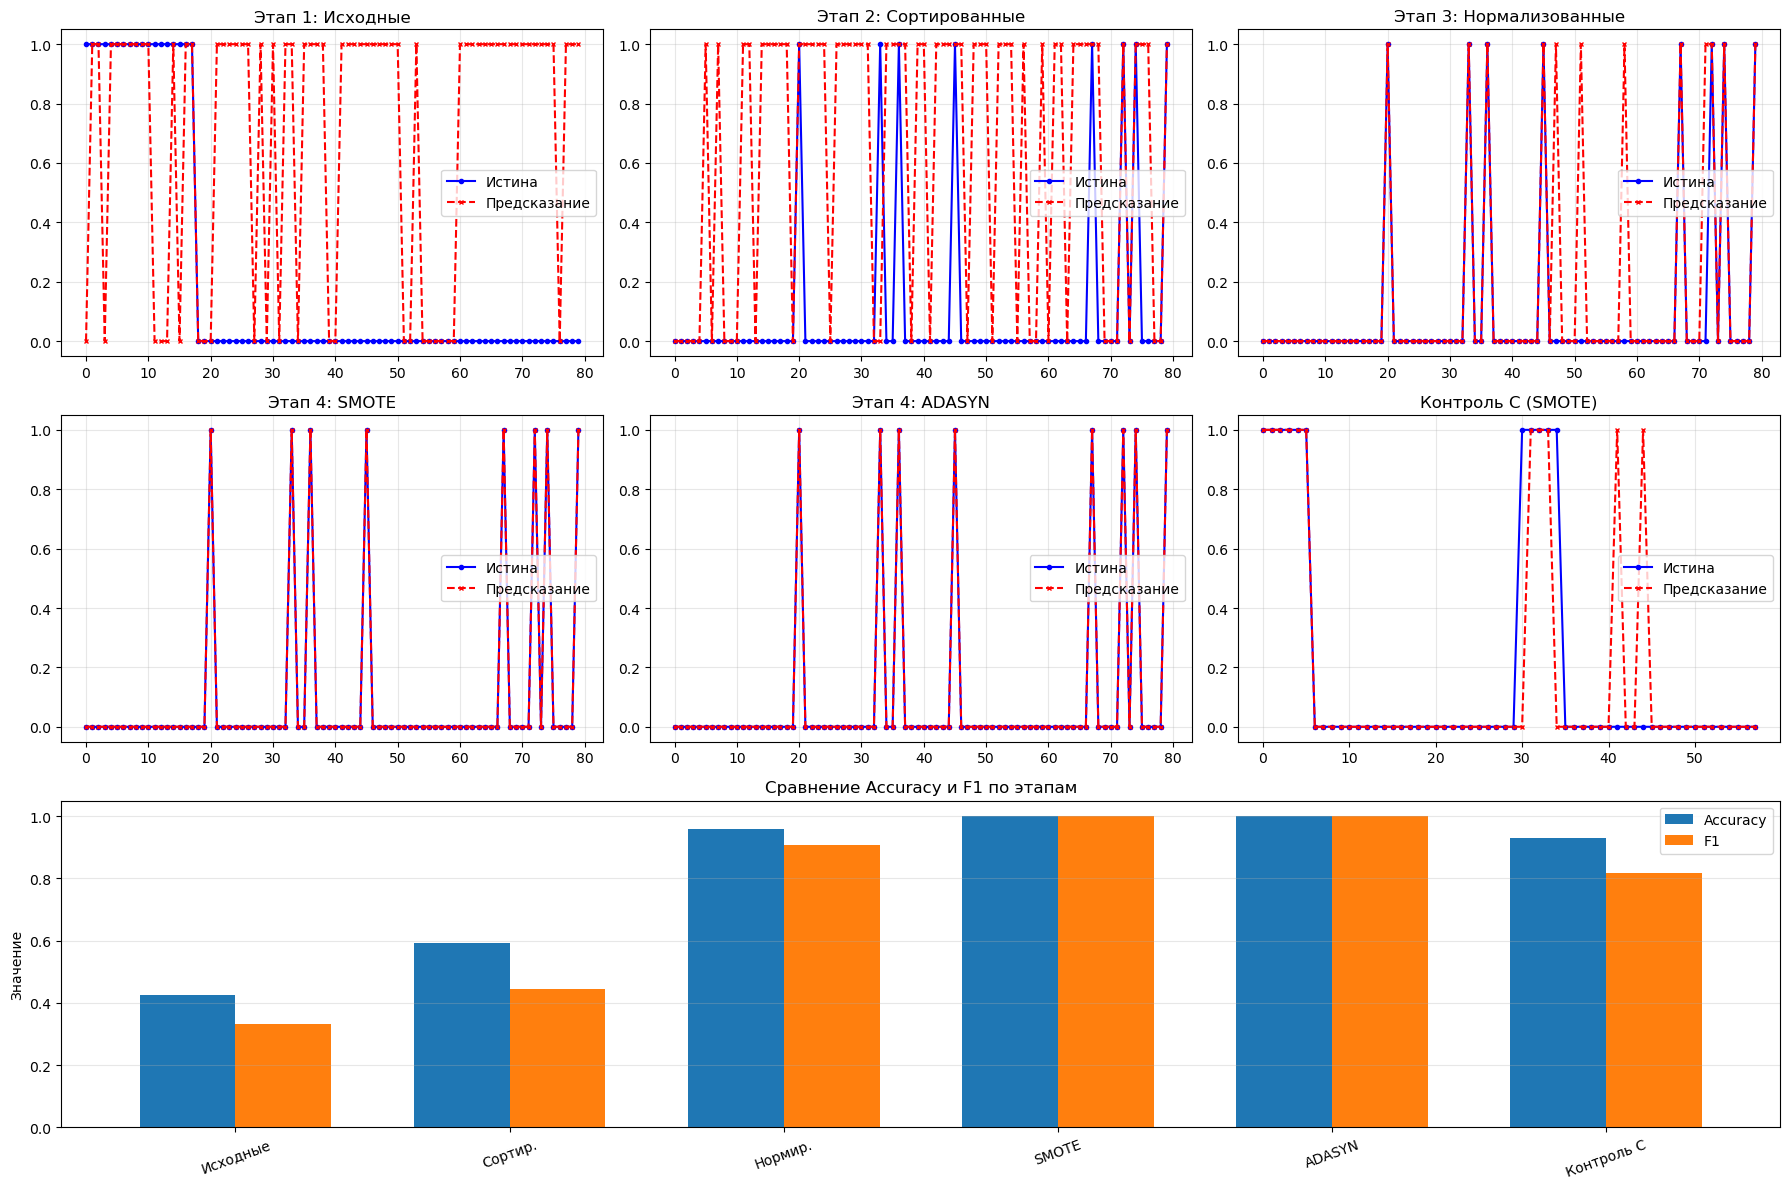

In [53]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import os
from sklearn.neural_network import MLPClassifier

# ------------------------------------------------------------
# Сводный рисунок (3x3 GridSpec) с гистограммой во всю нижнюю строку
# ------------------------------------------------------------
plot_dir = f'{DATA_DIR}\\plots'
os.makedirs(plot_dir, exist_ok=True)

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3)

# Функция для переобучения модели этапов 1 и 2
def get_stage12_predictions(stage_df, X_data, Y_data, random_state=42):
    best_row = stage_df.loc[stage_df['cv_f1_mean'].idxmax()]
    hidden = best_row['hidden_layers']
    activation = best_row['activation']
    solver = best_row['solver']
    max_iter = int(best_row['max_iter'])
    class_counts = np.bincount(Y_data)
    class_weights = {0: 1.0 / class_counts[0], 1: 1.0 / class_counts[1]}
    sample_weights = Y_data.map(class_weights).values
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden,
        activation=activation,
        solver=solver,
        max_iter=max_iter,
        random_state=random_state,
        early_stopping=False
    )
    mlp.fit(X_data, Y_data, sample_weight=sample_weights)
    return mlp.predict(X_data)

# --- Верхний ряд ---
# Этап 1
ax1 = fig.add_subplot(gs[0, 0])
if 'res_df' in locals() and not res_df.empty:
    y_pred_1 = get_stage12_predictions(res_df, X, Y)
    ax1.plot(Y.values[:80], 'bo-', label='Истина', markersize=3)
    ax1.plot(y_pred_1[:80], 'rx--', label='Предсказание', markersize=3)
    ax1.set_title('Этап 1: Исходные')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
else:
    ax1.text(0.5, 0.5, 'Нет данных', ha='center', va='center')

# Этап 2
ax2 = fig.add_subplot(gs[0, 1])
if 'res_sort_df' in locals() and not res_sort_df.empty:
    y_pred_2 = get_stage12_predictions(res_sort_df, X_sort, Y_sort)
    ax2.plot(Y_sort.values[:80], 'bo-', label='Истина', markersize=3)
    ax2.plot(y_pred_2[:80], 'rx--', label='Предсказание', markersize=3)
    ax2.set_title('Этап 2: Сортированные')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
else:
    ax2.text(0.5, 0.5, 'Нет данных', ha='center', va='center')

# Этап 3
ax3 = fig.add_subplot(gs[0, 2])
if 'best_norm' in locals():
    y_pred_norm = best_norm['model'].predict(X_norm)
    ax3.plot(Y_base.values[:80], 'bo-', label='Истина', markersize=3)
    ax3.plot(y_pred_norm[:80], 'rx--', label='Предсказание', markersize=3)
    ax3.set_title('Этап 3: Нормализованные')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
else:
    ax3.text(0.5, 0.5, 'Нет данных', ha='center', va='center')

# --- Средний ряд ---
# SMOTE
ax4 = fig.add_subplot(gs[1, 0])
if 'best_smote' in locals():
    y_pred_smote = best_smote['model'].predict(X_smote)
    ax4.plot(Y_smote[:80], 'bo-', label='Истина', markersize=3)
    ax4.plot(y_pred_smote[:80], 'rx--', label='Предсказание', markersize=3)
    ax4.set_title('Этап 4: SMOTE')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
else:
    ax4.text(0.5, 0.5, 'Нет данных', ha='center', va='center')

# ADASYN
ax5 = fig.add_subplot(gs[1, 1])
if 'best_adasyn' in locals():
    y_pred_adasyn = best_adasyn['model'].predict(X_adasyn)
    ax5.plot(Y_adasyn[:80], 'bo-', label='Истина', markersize=3)
    ax5.plot(y_pred_adasyn[:80], 'rx--', label='Предсказание', markersize=3)
    ax5.set_title('Этап 4: ADASYN')
    ax5.legend()
    ax5.grid(True, alpha=0.3)
else:
    ax5.text(0.5, 0.5, 'Нет данных', ha='center', va='center')

# Контроль C
ax6 = fig.add_subplot(gs[1, 2])
if 'best_name' in locals() and 'models' in locals():
    y_pred_best_C = models[best_name][0]
    ax6.plot(Y_C.values[:80], 'bo-', label='Истина', markersize=3)
    ax6.plot(y_pred_best_C[:80], 'rx--', label='Предсказание', markersize=3)
    ax6.set_title(f'Контроль C ({best_name})')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
else:
    ax6.text(0.5, 0.5, 'Нет данных', ha='center', va='center')

# --- Нижний ряд: гистограмма на всю ширину ---
ax_hist = fig.add_subplot(gs[2, :])

stages_names = []
acc_vals = []
f1_vals = []

if 'best_1' in locals():
    stages_names.append('Исходные')
    acc_vals.append(best_1['train_accuracy'])
    f1_vals.append(best_1['train_f1'])
if 'best_2' in locals():
    stages_names.append('Сортир.')
    acc_vals.append(best_2['train_accuracy'])
    f1_vals.append(best_2['train_f1'])
if 'best_norm' in locals():
    stages_names.append('Нормир.')
    acc_vals.append(best_norm['train_accuracy'])
    f1_vals.append(best_norm['train_f1'])
if 'best_smote' in locals():
    stages_names.append('SMOTE')
    acc_vals.append(best_smote['train_accuracy'])
    f1_vals.append(best_smote['train_f1'])
if 'best_adasyn' in locals():
    stages_names.append('ADASYN')
    acc_vals.append(best_adasyn['train_accuracy'])
    f1_vals.append(best_adasyn['train_f1'])
if 'best_name' in locals():
    stages_names.append('Контроль C')
    acc_vals.append(acc_C)
    f1_vals.append(f1_C)

if stages_names:
    x = np.arange(len(stages_names))
    width = 0.35
    ax_hist.bar(x - width/2, acc_vals, width, label='Accuracy')
    ax_hist.bar(x + width/2, f1_vals, width, label='F1')
    ax_hist.set_xticks(x)
    ax_hist.set_xticklabels(stages_names, rotation=20)
    ax_hist.set_ylabel('Значение')
    ax_hist.set_title('Сравнение Accuracy и F1 по этапам')
    ax_hist.legend()
    ax_hist.grid(axis='y', alpha=0.3)
else:
    ax_hist.text(0.5, 0.5, 'Нет данных', ha='center', va='center')

plt.tight_layout()
plt.savefig(f'{plot_dir}\\summary_results.png', dpi=150, bbox_inches='tight')
plt.show()